In [34]:
import numpy as np
import scipy.io.wavfile as wavfile
import matplotlib.pyplot as plt

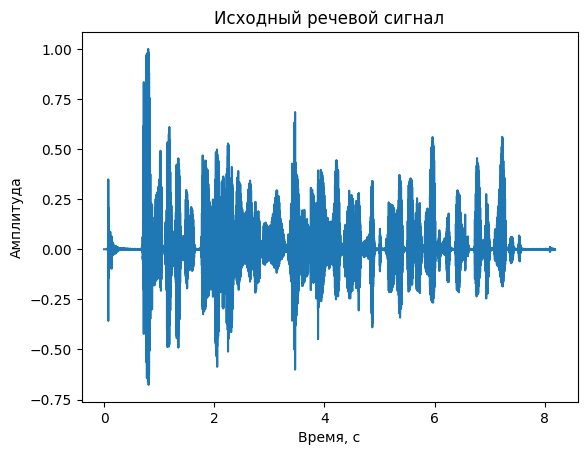

Частота дискретизации: 48000 Гц
Длина сигнала (в отсчётах): 392832
Длительность (в секундах): 8.184


In [35]:
fs, x = wavfile.read("input.wav")

# Если стерео — берём только один канал
if x.ndim > 1:
    x = x[:, 0]

# Нормализация
x = x.astype(np.float32)
x = x / np.max(np.abs(x))

t = np.linspace(0, len(x) / fs, len(x))
plt.figure()
plt.plot(t, x)
plt.title("Исходный речевой сигнал")
plt.xlabel("Время, с")
plt.ylabel("Амплитуда")
plt.show()
print("Частота дискретизации:", fs, "Гц")
print("Длина сигнала (в отсчётах):", len(x))
print("Длительность (в секундах):", len(x)/fs)

In [36]:
def shift(x, fs, dt, at, f):
    """
    Функция для создания смещённой версии сигнала с переменной задержкой.
    
    Параметры:
    x (ndarray): Входной сигнал.
    fs (int): Частота дискретизации (Гц).
    dt (float): Постоянная часть задержки (секунды).
    at (float): Амплитуда переменной части задержки (секунды).
    f (float): Частота изменения переменной части задержки (Гц).
    
    Возвращает:
    ndarray: Смещённый сигнал.
    """
    # Временная ось оригинального сигнала
    t_original = np.arange(len(x)) / fs
    
    # Генерация переменной задержки
    delta_t = dt + at * np.sin(2 * np.pi * f * t_original)
    
    # Проверка на строгое возрастание времени задержки
    if not np.all(np.diff(t_original + delta_t) > 0):
        print("Предупреждение: последовательный порядок отсчётов нарушен!")
    
    # Новая временная ось с учётом задержки
    t_shifted = t_original + delta_t
    
    # Интерполяция сигнала на новой временной сетке
    x_shifted = np.interp(t_original, t_shifted, x, left=0, right=0)
    
    return x_shifted

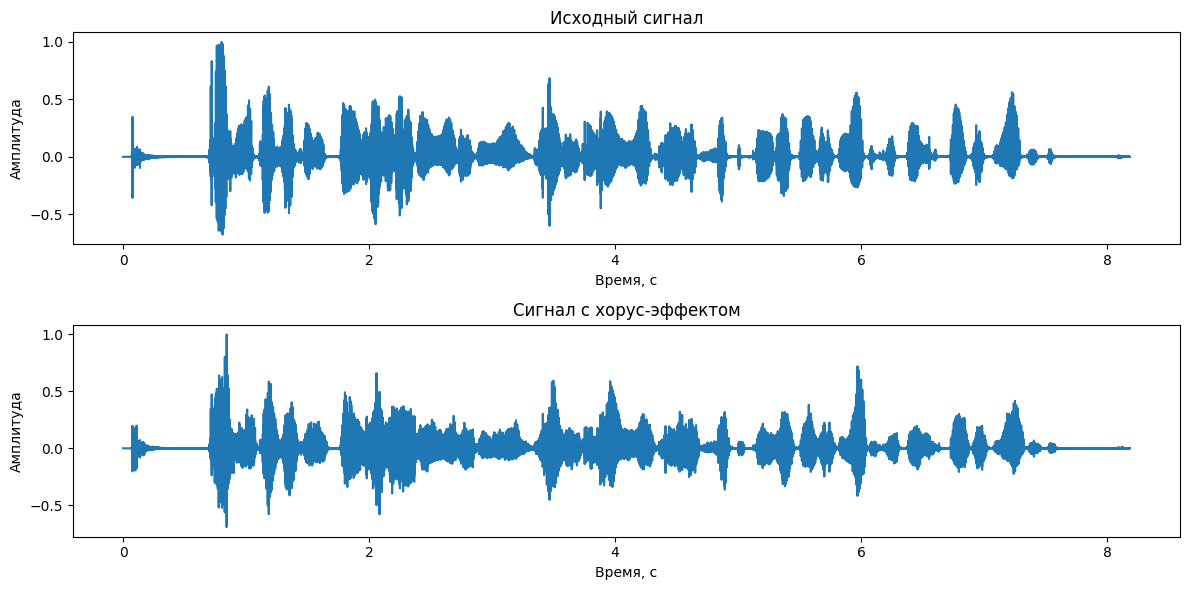

In [42]:
# Параметры для хорус-эффекта (можно настроить)
params = [
    {"dt": 0.02, "at": 0.01, "f": 0.5},  # Первая задержанная копия
    {"dt": 0.03, "at": 0.005, "f": 1.0},  # Вторая задержанная копия
]

# Создание выходного сигнала
output = x.copy()
for param in params:
    x_shifted = shift(x, fs, param["dt"], param["at"],param["f"])
    output += x_shifted

# Нормализация выходного сигнала
output = output / np.max(np.abs(output))

# Визуализация
plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plt.plot(np.arange(len(x)) / fs, x)
plt.title("Исходный сигнал")
plt.xlabel("Время, с")
plt.ylabel("Амплитуда")

plt.subplot(2, 1, 2)
plt.plot(np.arange(len(output)) / fs, output)
plt.title("Сигнал с хорус-эффектом")
plt.xlabel("Время, с")
plt.ylabel("Амплитуда")

plt.tight_layout()
plt.show()

# Сохранение результата в WAV-файл
wavfile.write("output.wav", fs, (output * 32767).astype(np.int16))